In [1]:
import pandas as pd
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.metrics.pairwise import rbf_kernel
from qiskit.circuit.library import pauli_feature_map
from pennylane.kernels import target_alignment
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

In [2]:
dataset = pd.read_csv("../dataset/riemann_features_v2.csv")

X = dataset.drop(columns=["distance"])
y = dataset["distance"]

X = X[2000:4000]
y = y[2000:4000]

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [3]:
random_forest_features = pd.read_csv("../results/data_analysis_v2/random_forest_feature_selection.csv")["feature"].tolist()
correlation_features = pd.read_csv("../results/data_analysis_v2/correlation_feature_selection.csv")["feature"].tolist()
gevrey_method_features = pd.read_csv("../results/data_analysis_v2/gevrey_method_feature_selection.csv")["feature"].tolist()
mrmr_10_features = pd.read_csv("../results/data_analysis_v2/mrmr_10_features.csv")["feature"].tolist()
rank_aggregation_features = pd.read_csv("../results/data_analysis_v2/selected_features.csv")["feature"].tolist()

features_map = {
    "Random Forest": random_forest_features[:10],
    "Correlation": correlation_features[:10],
    "Gevrey Method": gevrey_method_features[:10],
    "MRMR (10 features)": mrmr_10_features,
    "Rank Aggregation": rank_aggregation_features
}



# 2) Training Classical SVR

In [4]:
def run_classical_experiment(features_map):
    results = []

    param_grid = {
        "svr__C": [0.1, 1, 5, 10],
        "svr__epsilon": [0.001, 0.01, 0.1, 0.5],
        "svr__gamma": ["scale", 0.01, 0.1, 1.0]
    }

    for group_name, features in features_map.items():
        print(f"Running experiment for group: {group_name} with {len(features)} features")

        X_train_subset = X_train[features].to_numpy()
        X_test_subset = X_test[features].to_numpy()

        pipeline = Pipeline([
            ("scaler", MinMaxScaler()),
            ("svr", SVR(kernel="rbf"))
        ])

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_root_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=5),
            n_jobs=-1
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test_subset)

        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Group": group_name,
            "RMSE": rmse,
            "R2": r2,
            "Best C": grid.best_params_["svr__C"],
            "Best epsilon": grid.best_params_["svr__epsilon"],
            "Best gamma": grid.best_params_["svr__gamma"],
            "Features": len(features)
        })

    return pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)


In [5]:
df_standard = run_classical_experiment(features_map)
print(df_standard)
df_standard.to_csv("../results/experiment_11_v2/classical_results.csv", index=False)

Running experiment for group: Random Forest with 10 features
Running experiment for group: Correlation with 2 features
Running experiment for group: Gevrey Method with 4 features
Running experiment for group: MRMR (10 features) with 10 features
Running experiment for group: Rank Aggregation with 10 features
                Group      RMSE        R2  Best C  Best epsilon Best gamma  \
0    Rank Aggregation  0.241862  0.257552    10.0           0.1        0.1   
1       Gevrey Method  0.242845  0.251505     5.0           0.1        1.0   
2  MRMR (10 features)  0.250025  0.206590    10.0           0.1        0.1   
3       Random Forest  0.276539  0.029390     0.1           0.1      scale   
4         Correlation  0.280851 -0.001111     0.1           0.1       0.01   

   Features  
0        10  
1         4  
2        10  
3        10  
4         2  


In [6]:
from pysr import PySRRegressor

def run_pysr_experiment(features_map):
    results = []

    for group_name, features in features_map.items():
        print(f"Running PySR experiment for group: {group_name} with {len(features)} features")

        X_train_subset = X_train[features].to_numpy()
        X_test_subset = X_test[features].to_numpy()

        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train_subset)
        X_test_scaled = scaler.transform(X_test_subset)

        model = PySRRegressor(
            niterations=50,
            binary_operators=["+", "-", "*", "/"],
            unary_operators=["exp", "cos", "sin", "log", "sqrt"],
            populations=20,
            population_size=50,
            maxsize=25,
            parsimony=0.001,
            early_stop_condition="f(loss, complexity) = loss < 1e-4",
            turbo=True,
            verbosity=1,
            random_state=42,
            deterministic=True,
            procs=0,
            multithreading=False,
        )

        model.fit(
            X_train_scaled,
            y_train.to_numpy(),
            variable_names=features
        )

        y_pred = model.predict(X_test_scaled)

        rmse = root_mean_squared_error(y_test.to_numpy(), y_pred)
        r2 = r2_score(y_test.to_numpy(), y_pred)

        best_eq = model.sympy()

        eq_table = model.equations_
        best_row = eq_table.loc[eq_table["loss"].idxmin()]  # corrigido: loc em vez de iloc
        complexity = best_row["complexity"]

        results.append({
            "Group": group_name,
            "RMSE": rmse,
            "R2": r2,
            "Best Equation": str(best_eq),
            "Complexity": complexity,
            "Features": len(features)
        })

        eq_table.to_csv(
            f"../results/pysr_{group_name.replace(' ', '_').lower()}_equations.csv",
            index=False
        )

    return pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)


pysr_results = run_pysr_experiment(features_map)
print(pysr_results)
pysr_results.to_csv("../results/pysr_results.csv", index=False)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Running PySR experiment for group: Random Forest with 10 features


/home/gabriel/Documents/ic_qc/rgpe/venv/lib64/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
/home/gabriel/Documents/ic_qc/rgpe/venv/lib64/python3.13/site-packages/pysr/sr.py:2858: UserWarning: The `multithreading: bool` parameter has been deprecated in favor of `parallelism: Literal['multithreading', 'serial', 'multiprocessing']`.
Previous usage of `multithreading=True` (default) is now `parallelism='multithreading'`; `multithreading=False, procs=0` is now `parallelism='serial'`; and `multithreading=True, procs={int}` is now `parallelism='multiprocessing', procs={int}`.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 8.120e+04
Progress: 244 / 1000 total iterations (24.400%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.224e-02  0.000e+00  y = 0.5021
5           8.221e-02  7.487e-05  y = (z_integer * 0.054355) + 0.47886
6           8.094e-02  1.553e-02  y = cos(z_term_3 + -0.51247) * 0.5357
8           8.009e-02  5.289e-03  y = cos(cos(exp(z_term_3 * z_term_9))) * 0.55578
9           7.940e-02  8.731e-03  y = cos(cos(exp(z_term_3 * sqrt(z_term_9)))) * 0.55574
10          7.884e-02  7.045e-03  y = sin(sqrt(sin((z_term_3 + z_term_9) + 0.54907))) * 0.62...
                                      85
11          7.825e-02  7.462e-03  y = cos(cos(sin(sin((z_term_10 - z_term_5) / 0.37321)))) *...
                                       0.7375
13          7.763e-02  3

[ Info: Final population:
[ Info: Results saved to:


Running PySR experiment for group: Correlation with 2 features
  - outputs/20260313_194125_QsGNeZ/hall_of_fame.csv


...


Expressions evaluated per second: 8.560e+04
Progress: 233 / 1000 total iterations (23.300%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.224e-02  0.000e+00  y = 0.50203
4           8.104e-02  4.878e-03  y = cos(z_gram) * 0.57607
5           8.072e-02  3.982e-03  y = sin(cos(z_gram)) * 0.65801
6           7.820e-02  3.175e-02  y = cos(z_co_gram - z_gram) - 0.49241
7           7.275e-02  7.220e-02  y = sqrt(sin(z_gram / 0.32001)) * 0.54463
8           6.561e-02  1.033e-01  y = (z_gram * 4.7511) * (cos(z_gram) - 0.64564)
11          6.471e-02  4.587e-03  y = z_gram * ((z_gram * 4.1547) * cos(sin(z_gram) * 2.0894...
                                      ))
13          6.150e-02  2.543e-02  y = (sqrt(z_gram) * cos((z_gram * 3.3731) * z_gram)) - cos...
                             

[ Info: Final population:
[ Info: Results saved to:
/home/gabriel/Documents/ic_qc/rgpe/venv/lib64/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/gabriel/Documents/ic_qc/rgpe/venv/lib64/python3.13/site-packages/pysr/sr.py:2858: UserWarning: The `multithreading: bool` parameter has been deprecated in favor of `parallelism: Literal['multithreading', 'serial', 'multiprocessing']`.
Previous usage of `multithreading=True` (default) is now `parallelism='multithreading'`; `multithreading=False, procs=0` is now `parallelism='serial'`; and `multithreading=True, procs={int}` is now `parallelism='multiprocessing', procs={int}`.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 8.060e+04
Progress: 266 / 1000 total iterations (26.600%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.224e-02  0.000e+00  y = 0.5021
4           8.104e-02  4.878e-03  y = cos(z_gram) * 0.57606
5           7.278e-02  1.075e-01  y = sin(exp(z_gram)) + -0.47598
8           6.795e-02  2.289e-02  y = ((z_gram * -2.6724) + 2.4678) * sin(z_gram)
9           6.518e-02  4.170e-02  y = -0.46769 + cos(cos(z_gram + z_gram) - z_gram)
13          6.222e-02  1.161e-02  y = cos((((cos(z_gram) - z_gram) - z_gram) / 0.73857) + 0....
                                      22229) + -0.42958
14          5.900e-02  5.303e-02  y = sin(sin((exp(cos(-0.092063 - cos(z_gram / -0.2971))) *...
                                       0.83501) + -1.6))
17          5.892e-02

[ Info: Final population:
[ Info: Results saved to:
/home/gabriel/Documents/ic_qc/rgpe/venv/lib64/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/gabriel/Documents/ic_qc/rgpe/venv/lib64/python3.13/site-packages/pysr/sr.py:2858: UserWarning: The `multithreading: bool` parameter has been deprecated in favor of `parallelism: Literal['multithreading', 'serial', 'multiprocessing']`.
Previous usage of `multithreading=True` (default) is now `parallelism='multithreading'`; `multithreading=False, procs=0` is now `parallelism='serial'`; and `multithreading=True, procs={int}` is now `parallelism='multiprocessing', procs={int}`.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 7.880e+04
Progress: 230 / 1000 total iterations (23.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.224e-02  0.000e+00  y = 0.502
4           8.104e-02  4.878e-03  y = cos(z_gram) * 0.57606
6           7.903e-02  1.259e-02  y = cos(sqrt(z_gram)) * sqrt(z_gram)
7           6.760e-02  1.561e-01  y = (z_gram * (0.9072 - z_gram)) * 2.6694
8           6.645e-02  1.725e-02  y = sin((z_gram + z_gram) / 0.58688) * 0.55225
9           5.789e-02  1.379e-01  y = (sin(exp(z_gram - -1.5498)) - -0.64622) * 0.36238
10          5.511e-02  4.916e-02  y = exp(sin(exp(z_gram - -1.5537)) - 0.45121) * 0.35723
12          5.460e-02  4.636e-03  y = exp(sin(exp(z_gram - -1.6781) - 1.0492) + -0.106) * 0....
                                      25921
14          5

# 2) Traning Quantum SVR using the same best hyperparameters and features of classical SVR using Angle Embedding

## Verificando melhor kernel

In [82]:
N_QUBITS = 10
dev = qml.device("lightning.qubit", wires=N_QUBITS)


def ansatz_sem_hadamard(x, wires):
    qml.AngleEmbedding(x, wires=wires, rotation="X")
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, len(wires))),
        wires=wires,
        rotation=qml.RZ
    )
    qml.AngleEmbedding(x, wires=wires, rotation="Y")


def ansatz_sem_hadamard_XX(x, wires):
    qml.AngleEmbedding(x, wires=wires, rotation="X")
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, len(wires))),
        wires=wires,
        rotation=qml.RZ
    )
    qml.AngleEmbedding(x, wires=wires, rotation="X")


def ansatz_com_hadamard(x, wires):
    for w in wires:
        qml.Hadamard(wires=w)
    qml.AngleEmbedding(x, wires=wires, rotation="X")
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, len(wires))),
        wires=wires,
        rotation=qml.RZ
    )
    qml.AngleEmbedding(x, wires=wires, rotation="Y")


def ansatz_strong_sem_hadamard(x, wires):
    qml.AngleEmbedding(x, wires=wires, rotation="X")
    qml.StronglyEntanglingLayers(
        weights=np.zeros((1, len(wires), 3)),
        wires=wires
    )
    qml.AngleEmbedding(x, wires=wires, rotation="Y")


def ansatz_strong_com_hadamard(x, wires):
    for w in wires:
        qml.Hadamard(wires=w)
    qml.AngleEmbedding(x, wires=wires, rotation="X")
    qml.StronglyEntanglingLayers(
        weights=np.zeros((1, len(wires), 3)),
        wires=wires
    )
    qml.AngleEmbedding(x, wires=wires, rotation="Y")


@qml.qnode(dev)
def kernel_baseline(x1, x2):
    qml.AngleEmbedding(x1, wires=range(N_QUBITS), rotation="X")
    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(N_QUBITS), rotation="X")
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


@qml.qnode(dev)
def kernel_sem_hadamard(x1, x2):
    ansatz_sem_hadamard(x1, wires=range(N_QUBITS))
    qml.adjoint(ansatz_sem_hadamard)(x2, wires=range(N_QUBITS))
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


@qml.qnode(dev)
def kernel_sem_hadamard_XX(x1, x2):
    ansatz_sem_hadamard_XX(x1, wires=range(N_QUBITS))
    qml.adjoint(ansatz_sem_hadamard_XX)(x2, wires=range(N_QUBITS))
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


@qml.qnode(dev)
def kernel_com_hadamard(x1, x2):
    ansatz_com_hadamard(x1, wires=range(N_QUBITS))
    qml.adjoint(ansatz_com_hadamard)(x2, wires=range(N_QUBITS))
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


@qml.qnode(dev)
def kernel_strong_sem_hadamard(x1, x2):
    ansatz_strong_sem_hadamard(x1, wires=range(N_QUBITS))
    qml.adjoint(ansatz_strong_sem_hadamard)(x2, wires=range(N_QUBITS))
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


@qml.qnode(dev)
def kernel_strong_com_hadamard(x1, x2):
    ansatz_strong_com_hadamard(x1, wires=range(N_QUBITS))
    qml.adjoint(ansatz_strong_com_hadamard)(x2, wires=range(N_QUBITS))
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


@qml.qnode(dev)
def kernel_iqp(x1, x2):
    qml.IQPEmbedding(x1, wires=range(N_QUBITS))
    qml.adjoint(qml.IQPEmbedding)(x2, wires=range(N_QUBITS))
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


def kernel_rbf_fn(x1, x2):
    return rbf_kernel(x1.reshape(1, -1), x2.reshape(1, -1))[0, 0]


kernels = {
    "Baseline (AngleX sem entanglement)":   kernel_baseline,
    "Basic sem Hadamard":                   kernel_sem_hadamard,
    "Basic sem Hadamard XX":                kernel_sem_hadamard_XX,
    "Basic com Hadamard":                   kernel_com_hadamard,
    "Strong sem Hadamard":                  kernel_strong_sem_hadamard,
    "Strong com Hadamard":                  kernel_strong_com_hadamard,
    "IQP":                                  kernel_iqp,
    "RBF (baseline clássico)":              kernel_rbf_fn,
}


Kernel: Baseline (AngleX sem entanglement)
Geometric difference: 15.3073


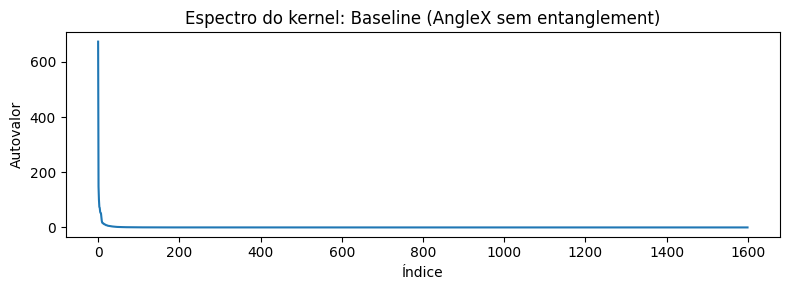

Autovalor máximo: 673.6565
Autovalor mínimo: 0.0000
Razão max/min: 38756275412.16

Kernel: Basic sem Hadamard
Geometric difference: 153.8874


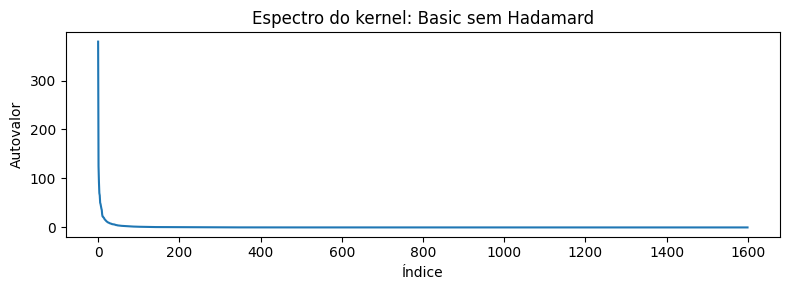

Autovalor máximo: 379.3830
Autovalor mínimo: 0.0000
Razão max/min: 146450805.67

Kernel: Basic sem Hadamard XX
Geometric difference: 148.9204


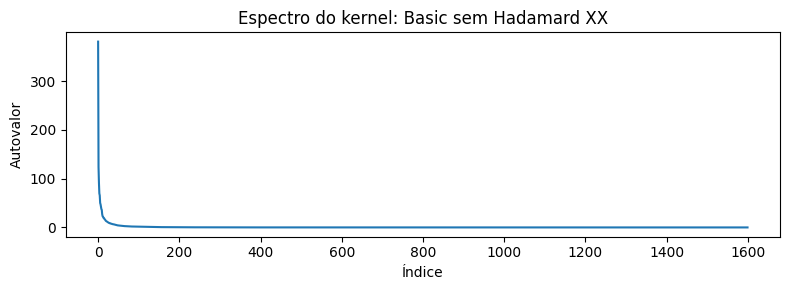

Autovalor máximo: 380.8026
Autovalor mínimo: 0.0000
Razão max/min: 199829717.87

Kernel: Basic com Hadamard
Geometric difference: 15.3073


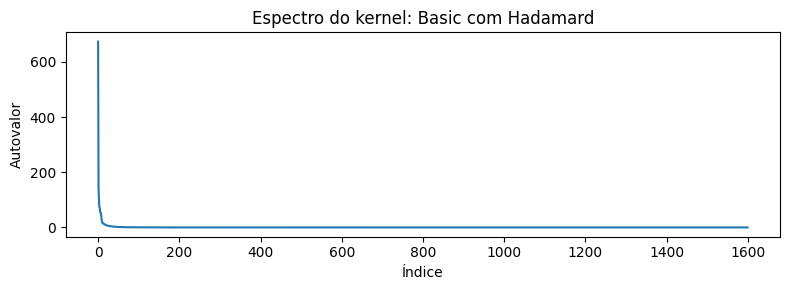

Autovalor máximo: 673.6565
Autovalor mínimo: 0.0000
Razão max/min: 38756274403.10

Kernel: Strong sem Hadamard
Geometric difference: 153.8874


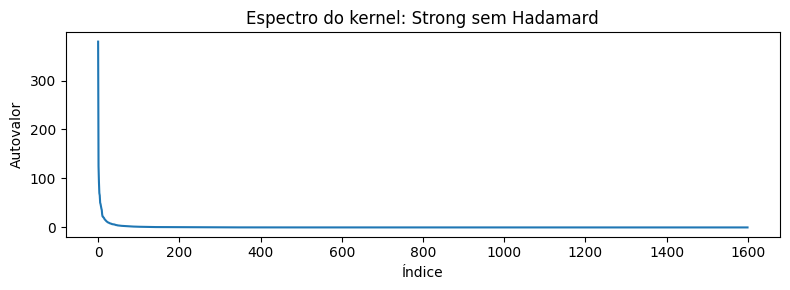

Autovalor máximo: 379.3830
Autovalor mínimo: 0.0000
Razão max/min: 146450805.67

Kernel: Strong com Hadamard
Geometric difference: 15.3073


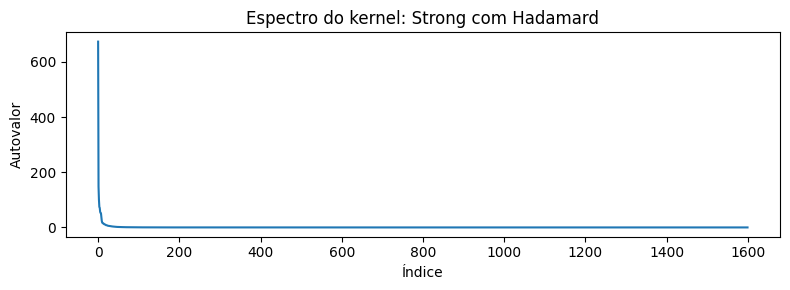

Autovalor máximo: 673.6565
Autovalor mínimo: 0.0000
Razão max/min: 38756274403.10

Kernel: IQP
Geometric difference: 3161.8548


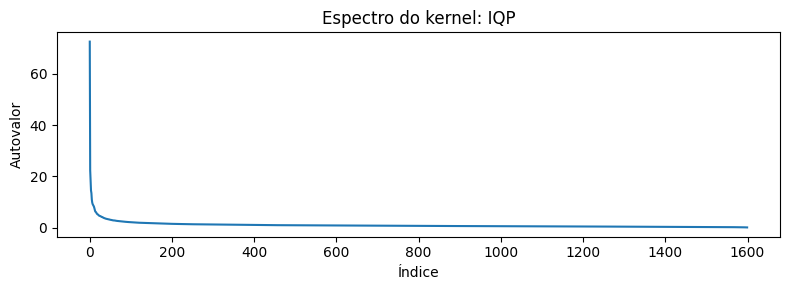

Autovalor máximo: 72.6262
Autovalor mínimo: 0.0823
Razão max/min: 882.72

Resultados salvos em ../results/experiment_11/spectral_analysis.csv


In [83]:
from scipy.linalg import sqrtm

features = features_map["Rank Aggregation"]
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_tr = scaler.fit_transform(X_train[features].to_numpy())


def geometric_difference(K_classical, K_quantum, eps=1e-7):
    """
    Compute geometric difference g between classical and quantum kernels.
    Formula: g = sqrt( || sqrt(K_quantum) @ inv(K_classical) @ sqrt(K_quantum) || )
    """
    N = K_classical.shape[0]

    # Regularize and invert K_classical
    Kc_reg = K_classical + eps * np.eye(N)
    Kc_inv = np.linalg.inv(Kc_reg)

    # Compute the square root of the quantum kernel
    sqrt_Kq = sqrtm(K_quantum)
    # Construct M = sqrt(Kq) @ Kc⁻¹ @ sqrt(Kq)
    M = sqrt_Kq @ Kc_inv @ sqrt_Kq

    # g = sqrt(max eigenvalue of M)
    max_eigval = np.max(np.linalg.eigvalsh(M))
    return np.sqrt(np.maximum(max_eigval, 0.0))


K_rbf = rbf_kernel(X_tr)

spectral_results = []

for name, kernel_func in kernels.items():
    if name == "RBF (baseline clássico)":
        continue

    print(f"\n{'='*60}")
    print(f"Kernel: {name}")
    print(f"{'='*60}")

    K_quantum = qml.kernels.kernel_matrix(X_tr, X_tr, kernel_func)

    g = geometric_difference(K_rbf, K_quantum)
    print(f"Geometric difference: {g:.4f}")

    eigenvalues = np.linalg.eigvalsh(K_quantum)
    eigenvalues_sorted = sorted(eigenvalues, reverse=True)

    plt.figure(figsize=(8, 3))
    plt.plot(eigenvalues_sorted)
    plt.title(f"Espectro do kernel: {name}")
    plt.xlabel("Índice")
    plt.ylabel("Autovalor")
    plt.tight_layout()
    plt.show()

    eig_max = eigenvalues_sorted[0]
    eig_min = eigenvalues_sorted[-1]
    ratio = eig_max / (eig_min + 1e-10)

    print(f"Autovalor máximo: {eig_max:.4f}")
    print(f"Autovalor mínimo: {eig_min:.4f}")
    print(f"Razão max/min: {ratio:.2f}")

    spectral_results.append({
        "Kernel": name,
        "Geometric Difference": g,
        "Eigenvalue Max": eig_max,
        "Eigenvalue Min": eig_min,
        "Eigenvalue Ratio Max/Min": ratio,
    })

df_spectral = pd.DataFrame(spectral_results)
df_spectral.to_csv("../results/experiment_11/spectral_analysis.csv", index=False)
print("\nResultados salvos em ../results/experiment_11/spectral_analysis.csv")

In [84]:
alignments = {}
for name, k in kernels.items():
    print("Calculando alignment para kernel:", name)
    alignment = target_alignment(X_tr, y_train, k, assume_normalized_kernel=True)
    alignments[name] = alignment
    print(f"{name}: {alignment:.4f}")


best = max(alignments, key=alignments.get)
print(f"\nMelhor kernel: {best} (alignment={alignments[best]:.4f})")

Calculando alignment para kernel: Baseline (AngleX sem entanglement)
Baseline (AngleX sem entanglement): 0.6678
Calculando alignment para kernel: Basic sem Hadamard
Basic sem Hadamard: 0.5608
Calculando alignment para kernel: Basic sem Hadamard XX
Basic sem Hadamard XX: 0.5677
Calculando alignment para kernel: Basic com Hadamard
Basic com Hadamard: 0.6678
Calculando alignment para kernel: Strong sem Hadamard
Strong sem Hadamard: 0.5608
Calculando alignment para kernel: Strong com Hadamard
Strong com Hadamard: 0.6678
Calculando alignment para kernel: IQP
IQP: 0.5289
Calculando alignment para kernel: RBF (baseline clássico)
RBF (baseline clássico): 0.7391

Melhor kernel: RBF (baseline clássico) (alignment=0.7391)


## Naive implementation, only rotations in X and standard scaling

In [85]:
results = []
param_grid = {
    "svr__C": [1, 5],
    "svr__epsilon": [0.01, 0.1]
}

features = features_map["Rank Aggregation"]
X_train_subset = X_train[features].to_numpy()
X_test_subset = X_test[features].to_numpy()


for kernel_name, kernel_func in kernels.items():
    if kernel_name == "RBF (baseline clássico)":
        continue
    print(f"Running quantum experiment for group: Rank Aggregation com kernel: {kernel_name}")

    kernel_mat = lambda A, B, kf=kernel_func: qml.kernels.kernel_matrix(A, B, kf)

    pipeline = Pipeline([
        ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
        ("svr", SVR(kernel=kernel_mat))
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid,
        scoring="neg_root_mean_squared_error",
        cv=TimeSeriesSplit(n_splits=5),
    )

    grid.fit(X_train_subset, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_subset)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Experiment": kernel_name,
        "RMSE": rmse,
        "R2": r2,
        "Best C": grid.best_params_["svr__C"],
        "Best epsilon": grid.best_params_["svr__epsilon"],
        "qubits": N_QUBITS,
    })

    print(f"RMSE: {rmse:.4f}, R2: {r2:.4f}, Best C: {grid.best_params_['svr__C']}, Best epsilon: {grid.best_params_['svr__epsilon']}\n")

print(pd.DataFrame(results))

Running quantum experiment for group: Rank Aggregation com kernel: Baseline (AngleX sem entanglement)
RMSE: 0.0787, R2: 0.9239, Best C: 5, Best epsilon: 0.01

Running quantum experiment for group: Rank Aggregation com kernel: Basic sem Hadamard
RMSE: 0.0724, R2: 0.9356, Best C: 5, Best epsilon: 0.01

Running quantum experiment for group: Rank Aggregation com kernel: Basic sem Hadamard XX
RMSE: 0.0736, R2: 0.9333, Best C: 5, Best epsilon: 0.01

Running quantum experiment for group: Rank Aggregation com kernel: Basic com Hadamard


KeyboardInterrupt: 

## Traning Quantum SVR using the same best hyperparameters and features of classical SVR using PauliFeatureMap

In [ ]:
def create_quantum_kernel(n_qubits, reps=3, entanglement="full", paulis=["ZZ", "Z"]):
    feature_map = pauli_feature_map(feature_dimension=n_qubits, reps=reps, entanglement=entanglement, paulis=paulis)
    sampler = StatevectorSampler()
    fidelity = ComputeUncompute(sampler=sampler)
    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)
    return quantum_kernel

In [ ]:
print("Running quantum experiments with Pauli Feature Map\n")

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_subset = X_train[features].to_numpy()
X_test_subset = X_test[features].to_numpy()

quantum_kernel = create_quantum_kernel(n_qubits=N_QUBITS, paulis=["ZZ", "ZZZ"], reps=2)

X_train_subset = X_train[features].to_numpy()
X_test_subset = X_test[features].to_numpy()

pipeline = Pipeline([
    ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
    ("svr", SVR(kernel=quantum_kernel.evaluate))
])

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=5),
)

grid.fit(X_train_subset, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_subset)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results.append({
    "Experiment": "Quantum SVR Pauli Feature Map Kernel",
    "RMSE": rmse,
    "R2": r2,
    "Best C": grid.best_params_["svr__C"],
    "Best epsilon": grid.best_params_["svr__epsilon"],
    "qubits": N_QUBITS,
})

Running quantum experiments with Pauli Feature Map



KeyboardInterrupt: 

In [ ]:
quantum_df = pd.DataFrame(results)
print(quantum_df)
quantum_df.to_csv("../results/experiment_11/quantum_results.csv", index=False)